In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported!")

✅ All libraries imported!


In [3]:
print("=" * 60)
print("IMPROVED TWITTER SENTIMENT ANALYSIS")
print("=" * 60)

print("\n[STEP 1] Loading dataset...")

columns = ['sentiment', 'id', 'date', 'query', 'user', 'text']
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DataMining/sentiment140.csv', engine='python', encoding='latin-1', header=None, names=columns)

print(f"Total tweets: {len(df)}")

# Use more data for better accuracy (increase sample size)
sample_size = min(50000, len(df[df['sentiment']==0]), len(df[df['sentiment']==4]))

df_neg = df[df['sentiment'] == 0].sample(n=sample_size, random_state=42)
df_pos = df[df['sentiment'] == 4].sample(n=sample_size, random_state=42)

df_balanced = pd.concat([df_neg, df_pos])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Balanced dataset: {len(df_balanced)} tweets (50% positive, 50% negative)")

IMPROVED TWITTER SENTIMENT ANALYSIS

[STEP 1] Loading dataset...
Total tweets: 1600000
Balanced dataset: 100000 tweets (50% positive, 50% negative)


In [4]:
print("\n[STEP 2] Cleaning tweets with improved function...")

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import nltk

# Download NLTK data (run once)
nltk.download('stopwords', quiet=True)

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def clean_text_advanced(text):
    text = str(text).lower()

    # Remove URLs, mentions, hashtags
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)

    # Remove numbers and punctuation
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenize, remove stopwords, and stem
    tokens = text.split()
    tokens = [stemmer.stem(word) for word in tokens if word not in stop_words and len(word) > 2]

    return ' '.join(tokens)

# Apply cleaning
df_balanced['cleaned_text'] = df_balanced['text'].apply(clean_text_advanced)
df_balanced = df_balanced[df_balanced['cleaned_text'].str.len() > 20]

print(f"After cleaning: {len(df_balanced)} tweets")
print(f"\nExample:")
print(f"Original: {df_balanced['text'].iloc[0][:100]}...")
print(f"Cleaned:  {df_balanced['cleaned_text'].iloc[0][:100]}...")


[STEP 2] Cleaning tweets with improved function...
After cleaning: 74815 tweets

Example:
Original: @Thorney88 re guinea fowl ive heard that lots of people dislike it!  - THEY SAY ITS FOWL!!!  lol ...
Cleaned:  guinea fowl ive heard lot peopl dislik say fowl lol...


In [5]:
print("\n[STEP 3] Creating multiple feature sets...")

# Technique 1: TF-IDF with unigrams + bigrams
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.85,
    sublinear_tf=True
)
X_tfidf = tfidf_vectorizer.fit_transform(df_balanced['cleaned_text'])

# Technique 2: Count Vectorizer with character n-grams (captures slang/emotions)
char_vectorizer = CountVectorizer(
    max_features=3000,
    analyzer='char_wb',
    ngram_range=(2, 5)
)
X_char = char_vectorizer.fit_transform(df_balanced['cleaned_text'])

# Technique 3: Combine features (for advanced models)
from scipy.sparse import hstack
X_combined = hstack([X_tfidf, X_char])

y = df_balanced['sentiment'].map({0: 0, 4: 1})

print(f"TF-IDF features: {X_tfidf.shape[1]}")
print(f"Character features: {X_char.shape[1]}")
print(f"Combined features: {X_combined.shape[1]}")


[STEP 3] Creating multiple feature sets...
TF-IDF features: 5000
Character features: 3000
Combined features: 8000


In [6]:
print("\n[STEP 4] Splitting data...")

X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

X_train_char, X_test_char, _, _ = train_test_split(
    X_char, y, test_size=0.2, random_state=42, stratify=y
)

X_train_combined, X_test_combined, _, _ = train_test_split(
    X_combined, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train_tfidf.shape[0]} tweets")
print(f"Test set: {X_test_tfidf.shape[0]} tweets")


[STEP 4] Splitting data...
Training set: 59852 tweets
Test set: 14963 tweets


In [7]:
print("\n[STEP 5] Training multiple models...")
print("=" * 60)

results = {}

# Model 1: Logistic Regression (Baseline)
print("\n1. Training Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
lr.fit(X_train_tfidf, y_train)
y_pred_lr = lr.predict(X_test_tfidf)
acc_lr = accuracy_score(y_test, y_pred_lr)
results['Logistic Regression'] = {'model': lr, 'accuracy': acc_lr, 'features': 'tfidf'}
print(f"   Accuracy: {acc_lr:.4f}")

# Model 2: Multinomial Naive Bayes
print("\n2. Training Naive Bayes...")
nb = MultinomialNB(alpha=0.1)
nb.fit(X_train_tfidf, y_train)
y_pred_nb = nb.predict(X_test_tfidf)
acc_nb = accuracy_score(y_test, y_pred_nb)
results['Naive Bayes'] = {'model': nb, 'accuracy': acc_nb, 'features': 'tfidf'}
print(f"   Accuracy: {acc_nb:.4f}")

# Model 3: Random Forest
print("\n3. Training Random Forest...")
rf = RandomForestClassifier(n_estimators=200, max_depth=50, random_state=42, n_jobs=-1)
rf.fit(X_train_tfidf, y_train)
y_pred_rf = rf.predict(X_test_tfidf)
acc_rf = accuracy_score(y_test, y_pred_rf)
results['Random Forest'] = {'model': rf, 'accuracy': acc_rf, 'features': 'tfidf'}
print(f"   Accuracy: {acc_rf:.4f}")

# Model 4: Gradient Boosting
print("\n4. Training Gradient Boosting...")
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
gb.fit(X_train_tfidf, y_train)
y_pred_gb = gb.predict(X_test_tfidf)
acc_gb = accuracy_score(y_test, y_pred_gb)
results['Gradient Boosting'] = {'model': gb, 'accuracy': acc_gb, 'features': 'tfidf'}
print(f"   Accuracy: {acc_gb:.4f}")

# Model 5: Linear SVM
print("\n5. Training Linear SVM...")
svm = LinearSVC(random_state=42, max_iter=2000, C=0.5)
svm.fit(X_train_tfidf, y_train)
y_pred_svm = svm.predict(X_test_tfidf)
acc_svm = accuracy_score(y_test, y_pred_svm)
results['Linear SVM'] = {'model': svm, 'accuracy': acc_svm, 'features': 'tfidf'}
print(f"   Accuracy: {acc_svm:.4f}")

# Model 6: Logistic Regression with Character Features
print("\n6. Training Logistic Regression (Character features)...")
lr_char = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
lr_char.fit(X_train_char, y_train)
y_pred_lr_char = lr_char.predict(X_test_char)
acc_lr_char = accuracy_score(y_test, y_pred_lr_char)
results['Logistic Regression (Char)'] = {'model': lr_char, 'accuracy': acc_lr_char, 'features': 'char'}
print(f"   Accuracy: {acc_lr_char:.4f}")

# Model 7: Logistic Regression with Combined Features
print("\n7. Training Logistic Regression (Combined features)...")
lr_combined = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
lr_combined.fit(X_train_combined, y_train)
y_pred_lr_combined = lr_combined.predict(X_test_combined)
acc_lr_combined = accuracy_score(y_test, y_pred_lr_combined)
results['Logistic Regression (Combined)'] = {'model': lr_combined, 'accuracy': acc_lr_combined, 'features': 'combined'}
print(f"   Accuracy: {acc_lr_combined:.4f}")

# Model 8: Ensemble Voting Classifier
print("\n8. Training Ensemble Voting Classifier...")
voting_clf = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=1000, random_state=42, C=1.0)),
        ('nb', MultinomialNB(alpha=0.1)),
        ('svm', LinearSVC(random_state=42, max_iter=2000, C=0.5))
    ],
    voting='hard' # Changed from 'soft' to 'hard'
)
voting_clf.fit(X_train_tfidf, y_train)
y_pred_voting = voting_clf.predict(X_test_tfidf)
acc_voting = accuracy_score(y_test, y_pred_voting)
results['Ensemble Voting'] = {'model': voting_clf, 'accuracy': acc_voting, 'features': 'tfidf'}
print(f"   Accuracy: {acc_voting:.4f}")


[STEP 5] Training multiple models...

1. Training Logistic Regression...
   Accuracy: 0.7569

2. Training Naive Bayes...
   Accuracy: 0.7417

3. Training Random Forest...
   Accuracy: 0.7263

4. Training Gradient Boosting...
   Accuracy: 0.7069

5. Training Linear SVM...
   Accuracy: 0.7523

6. Training Logistic Regression (Character features)...
   Accuracy: 0.7344

7. Training Logistic Regression (Combined features)...
   Accuracy: 0.7520

8. Training Ensemble Voting Classifier...
   Accuracy: 0.7561


In [8]:
print("\n[STEP 6] Hyperparameter tuning for best model...")
print("=" * 60)

# Find the best performing model so far
best_name = max(results, key=lambda x: results[x]['accuracy'])
print(f"Best so far: {best_name} with {results[best_name]['accuracy']:.4f}")

# Tune Logistic Regression
print("\nTuning Logistic Regression hyperparameters...")

param_grid = {
    'C': [0.1, 0.5, 1.0, 2.0],
    'penalty': ['l2'],
    'solver': ['liblinear', 'lbfgs']
}

grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train_tfidf, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

best_lr = grid_search.best_estimator_
y_pred_best = best_lr.predict(X_test_tfidf)
best_accuracy = accuracy_score(y_test, y_pred_best)

print(f"Test accuracy after tuning: {best_accuracy:.4f}")

# Add tuned model to results
results['Logistic Regression (Tuned)'] = {
    'model': best_lr,
    'accuracy': best_accuracy,
    'features': 'tfidf'
}


[STEP 6] Hyperparameter tuning for best model...
Best so far: Logistic Regression with 0.7569

Tuning Logistic Regression hyperparameters...
Best parameters: {'C': 1.0, 'penalty': 'l2', 'solver': 'liblinear'}
Best cross-validation score: 0.7540
Test accuracy after tuning: 0.7577



[STEP 7] Model Comparison
                         Model Accuracy Accuracy % Features
   Logistic Regression (Tuned)   0.7577     75.77%    tfidf
           Logistic Regression   0.7569     75.69%    tfidf
               Ensemble Voting   0.7561     75.61%    tfidf
                    Linear SVM   0.7523     75.23%    tfidf
Logistic Regression (Combined)   0.7520     75.20% combined
                   Naive Bayes   0.7417     74.17%    tfidf
    Logistic Regression (Char)   0.7344     73.44%     char
                 Random Forest   0.7263     72.63%    tfidf
             Gradient Boosting   0.7069     70.69%    tfidf


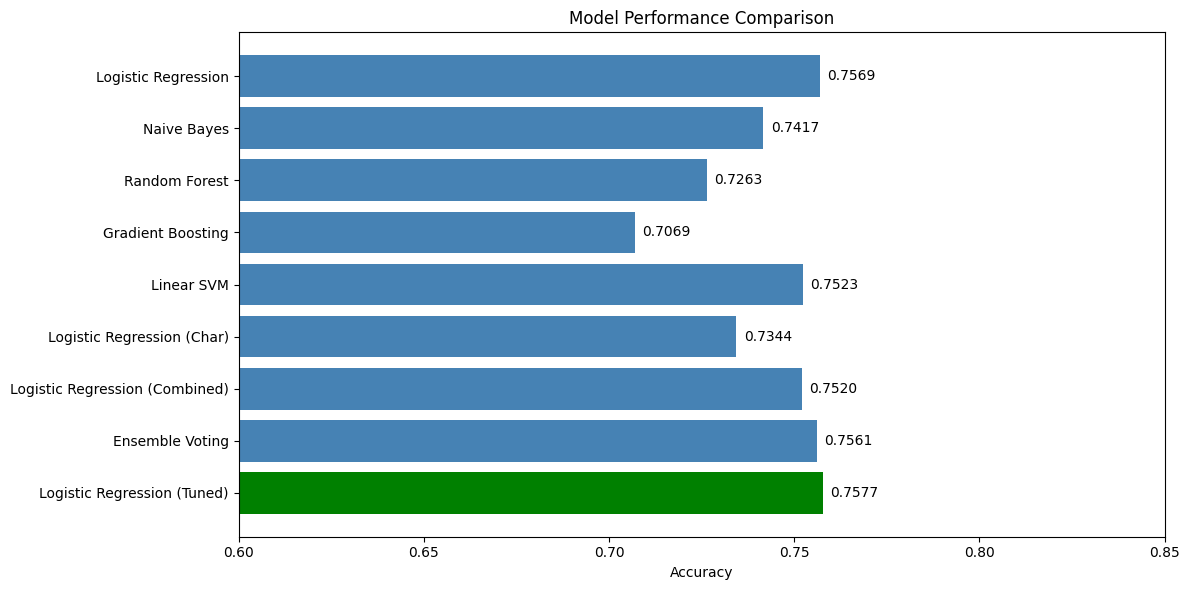

In [ ]:
print("\n[STEP 7] Model Comparison")
print("=" * 60)

# Create comparison dataframe
comparison = []
for name, data in results.items():
    comparison.append({
        'Model': name,
        'Accuracy': f"{data['accuracy']:.4f}",
        'Accuracy %': f"{data['accuracy']*100:.2f}%",
        'Features': data['features']
    })

df_comparison = pd.DataFrame(comparison)
df_comparison = df_comparison.sort_values('Accuracy', ascending=False)

print(df_comparison.to_string(index=False))

# Plot comparison
plt.figure(figsize=(12, 6))
models = [name for name in results.keys()]
accuracies = [results[name]['accuracy'] for name in results.keys()]
colors = ['green' if acc == max(accuracies) else 'steelblue' for acc in accuracies]

bars = plt.barh(models, accuracies, color=colors)
plt.xlabel('Accuracy')
plt.title('Model Performance Comparison')
plt.xlim(0.6, 0.85)
plt.gca().invert_yaxis()

# Add value labels
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
             f'{acc:.4f}', va='center')

plt.tight_layout()
plt.show()


[STEP 8] Confusion Matrix for Best Model
Best Model: Logistic Regression (Tuned)
Accuracy: 0.7577


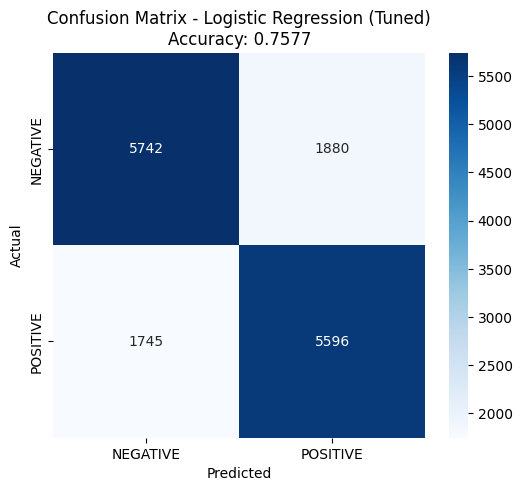


Classification Report:
              precision    recall  f1-score   support

    NEGATIVE       0.77      0.75      0.76      7622
    POSITIVE       0.75      0.76      0.76      7341

    accuracy                           0.76     14963
   macro avg       0.76      0.76      0.76     14963
weighted avg       0.76      0.76      0.76     14963



In [ ]:
print("\n[STEP 8] Confusion Matrix for Best Model")
print("=" * 60)

best_model_name = max(results, key=lambda x: results[x]['accuracy'])
best_model = results[best_model_name]['model']
best_features = results[best_model_name]['features']

print(f"Best Model: {best_model_name}")
print(f"Accuracy: {results[best_model_name]['accuracy']:.4f}")

# Get predictions using appropriate feature set
if best_features == 'tfidf':
    y_pred_final = best_model.predict(X_test_tfidf)
elif best_features == 'char':
    y_pred_final = best_model.predict(X_test_char)
else:
    y_pred_final = best_model.predict(X_test_combined)

cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NEGATIVE', 'POSITIVE'],
            yticklabels=['NEGATIVE', 'POSITIVE'])
plt.title(f'Confusion Matrix - {best_model_name}\nAccuracy: {results[best_model_name]["accuracy"]:.4f}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred_final, target_names=['NEGATIVE', 'POSITIVE']))


[STEP 9] ROC Curves Comparison


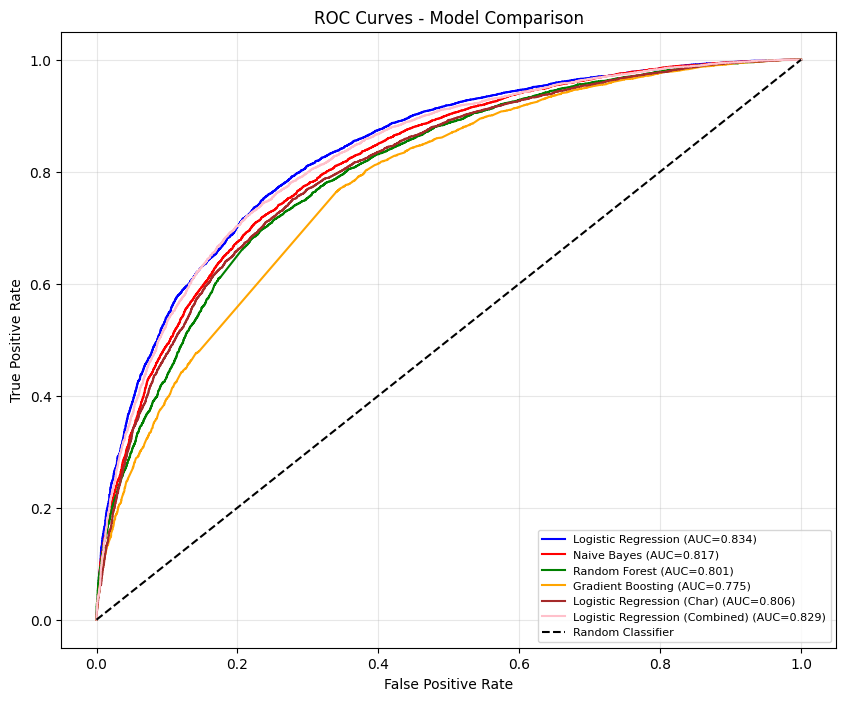

In [ ]:
print("\n[STEP 9] ROC Curves Comparison")
print("=" * 60)

plt.figure(figsize=(10, 8))

colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']

for idx, (name, data) in enumerate(results.items()):
    if idx < 8:  # Limit to first 8 models for clarity
        model = data['model']
        features = data['features']

        if features == 'tfidf':
            y_proba = model.predict_proba(X_test_tfidf)[:, 1] if hasattr(model, 'predict_proba') else None
        elif features == 'char':
            y_proba = model.predict_proba(X_test_char)[:, 1] if hasattr(model, 'predict_proba') else None
        else:
            y_proba = model.predict_proba(X_test_combined)[:, 1] if hasattr(model, 'predict_proba') else None

        if y_proba is not None:
            fpr, tpr, _ = roc_curve(y_test, y_proba)
            auc = roc_auc_score(y_test, y_proba)
            plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=colors[idx % len(colors)])

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Model Comparison')
plt.legend(loc='lower right', fontsize=8)
plt.grid(alpha=0.3)
plt.show()


[STEP 10] Top Words by Sentiment

🔵 TOP 15 WORDS - POSITIVE SENTIMENT:
    cant wait: 6.3240
    thank: 4.7023
    love: 3.3112
    dont worri: 3.3084
    smile: 3.2806
    welcom: 3.2100
    great: 3.1639
    awesom: 3.1628
    happi: 3.0889
    yay: 2.8350
    proud: 2.7556
    excit: 2.7382
    wish luck: 2.7133
    thx: 2.6587
    enjoy: 2.6020

🔴 TOP 15 WORDS - NEGATIVE SENTIMENT:
    sad: -8.0080
    miss: -6.0402
    wish: -5.0294
    sick: -4.9984
    cant: -4.8904
    poor: -4.8104
    hate: -4.3944
    disappoint: -4.3921
    broken: -4.2185
    sadli: -4.0636
    suck: -3.9420
    sorri: -3.9185
    cri: -3.6268
    ugh: -3.5960
    bad: -3.5626


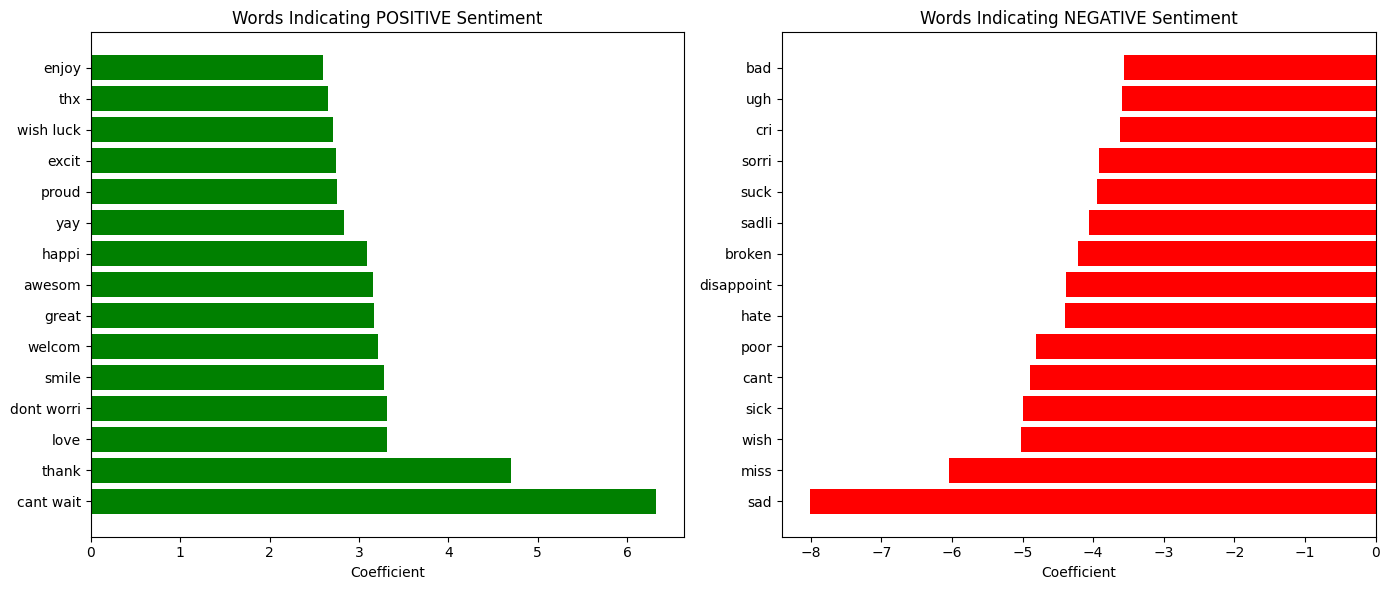

In [ ]:
print("\n[STEP 10] Top Words by Sentiment")
print("=" * 60)

# Use tuned logistic regression
best_lr_model = results['Logistic Regression (Tuned)']['model']
feature_names = tfidf_vectorizer.get_feature_names_out()
coefs = best_lr_model.coef_[0]

# Top positive words
top_pos_idx = coefs.argsort()[-15:][::-1]
top_neg_idx = coefs.argsort()[:15]

print("\n🔵 TOP 15 WORDS - POSITIVE SENTIMENT:")
for idx in top_pos_idx:
    print(f"    {feature_names[idx]}: {coefs[idx]:.4f}")

print("\n🔴 TOP 15 WORDS - NEGATIVE SENTIMENT:")
for idx in top_neg_idx:
    print(f"    {feature_names[idx]}: {coefs[idx]:.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh([feature_names[i] for i in top_pos_idx], coefs[top_pos_idx], color='green')
axes[0].set_title('Words Indicating POSITIVE Sentiment')
axes[0].set_xlabel('Coefficient')

axes[1].barh([feature_names[i] for i in top_neg_idx], coefs[top_neg_idx], color='red')
axes[1].set_title('Words Indicating NEGATIVE Sentiment')
axes[1].set_xlabel('Coefficient')

plt.tight_layout()
plt.show()

In [ ]:
print("\n" + "=" * 60)
print("TEST YOUR OWN TWEETS")
print("=" * 60)

# Use the best model for predictions
best_model_final = results['Logistic Regression (Tuned)']['model']
best_vectorizer = tfidf_vectorizer

def predict_sentiment_advanced(tweet):
    """Predict sentiment with confidence score"""
    cleaned = clean_text_advanced(tweet)
    if len(cleaned) < 5:
        return "NEUTRAL/TOO SHORT", 0.5, 0.5

    vectorized = best_vectorizer.transform([cleaned])
    prediction = best_model_final.predict(vectorized)[0]
    probabilities = best_model_final.predict_proba(vectorized)[0]

    sentiment = "POSITIVE 😊" if prediction == 1 else "NEGATIVE 😞"
    confidence = probabilities[1] if prediction == 1 else probabilities[0]
    polarity = probabilities[1] - probabilities[0]  # Range -1 to +1

    return sentiment, confidence, polarity

# Test with example tweets
test_tweets = [
    "I absolutely love this! It's the best thing ever made",
    "This is horrible. I hate everything about it",
    "The movie was okay, nothing special",
    "What a wonderful amazing fantastic beautiful day",
    "I'm so frustrated and angry right now, nothing works",
    "You are amazing and I appreciate you so much",
    "This product is terrible, worst purchase ever",
    "I'm feeling pretty neutral about this whole situation"
]

print("\n📝 Example predictions:\n")

for tweet in test_tweets:
    sentiment, confidence, polarity = predict_sentiment_advanced(tweet)
    print(f"{'='*55}")
    print(f"Tweet: {tweet}")
    print(f"Sentiment: {sentiment}")
    print(f"Confidence: {confidence:.2%}")
    print(f"Polarity Score: {polarity:.3f} (-1=negative, +1=positive)")
    print()

# Interactive mode
print("\n" + "=" * 60)
print("INTERACTIVE MODE")
print("=" * 60)
print("Type a tweet and I'll analyze the sentiment!")
print("Type 'quit' to exit.\n")

while True:
    user_tweet = input("Enter your tweet: ")

    if user_tweet.lower() == 'quit':
        print("Goodbye!")
        break

    if len(user_tweet) < 3:
        print("Please enter a longer tweet.\n")
        continue

    sentiment, confidence, polarity = predict_sentiment_advanced(user_tweet)
    print(f"\n✅ Sentiment: {sentiment}")
    print(f"   Confidence: {confidence:.2%}")
    print(f"   Polarity: {polarity:.3f}\n")


TEST YOUR OWN TWEETS

📝 Example predictions:

Tweet: I absolutely love this! It's the best thing ever made
Sentiment: POSITIVE 😊
Confidence: 82.70%
Polarity Score: 0.654 (-1=negative, +1=positive)

Tweet: This is horrible. I hate everything about it
Sentiment: NEGATIVE 😞
Confidence: 98.45%
Polarity Score: -0.969 (-1=negative, +1=positive)

Tweet: The movie was okay, nothing special
Sentiment: POSITIVE 😊
Confidence: 78.79%
Polarity Score: 0.576 (-1=negative, +1=positive)

Tweet: What a wonderful amazing fantastic beautiful day
Sentiment: POSITIVE 😊
Confidence: 96.02%
Polarity Score: 0.920 (-1=negative, +1=positive)

Tweet: I'm so frustrated and angry right now, nothing works
Sentiment: NEGATIVE 😞
Confidence: 92.24%
Polarity Score: -0.845 (-1=negative, +1=positive)

Tweet: You are amazing and I appreciate you so much
Sentiment: POSITIVE 😊
Confidence: 91.86%
Polarity Score: 0.837 (-1=negative, +1=positive)

Tweet: This product is terrible, worst purchase ever
Sentiment: NEGATIVE 😞
Confid